# Preprocessing

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyinform.utils import coalesce_series, coalesce
from pyinform import transfer_entropy
import networkx as nx
from scipy import stats
import sys
print(sys.executable)

c:\Users\taoni\Documents\jc\venv\Scripts\python.exe


### Load data

In [3]:
data = np.genfromtxt("data.csv", delimiter=",")

# 1 Data normalization

[  5.21560352   6.09997621  13.02125436 ...  34.0496583  -12.15346486
  17.27890364]


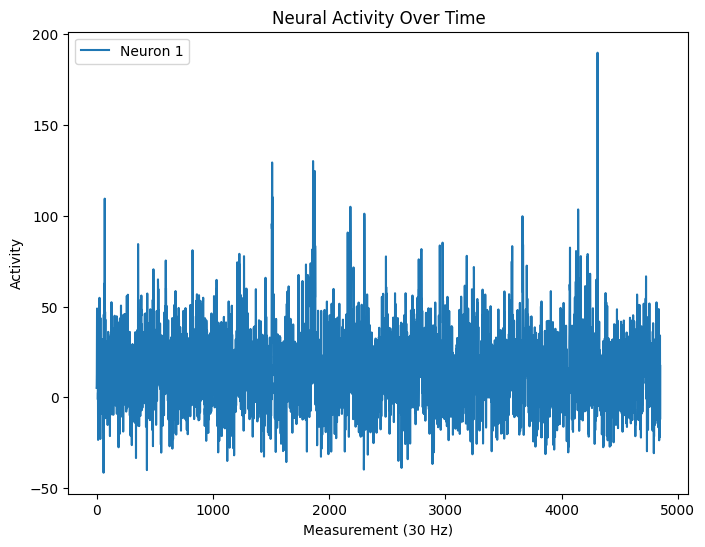

In [16]:
# Neuronal activity for neuron 1
print(data[0])

# Plot data for neuron 1
plt.figure(figsize=(8, 6))
plt.plot(np.arange(0, data.shape[1]), data[0,:], label="Neuron 1")
# plt.plot(np.arange(0, data.shape[1]), data[1,:], label="Neuron 2")
# plt.plot(np.arange(0, data.shape[1]), data[2,:], label="Neuron 3")
# plt.plot(np.arange(0, data.shape[1]), data[3,:], label="Neuron 4")
# plt.plot(np.arange(0, data.shape[1]), data[4,:], label="Neuron 5")

plt.xlabel("Measurement (30 Hz)")
plt.ylabel("Activity")
plt.title("Neural Activity Over Time")
plt.legend()
plt.show()

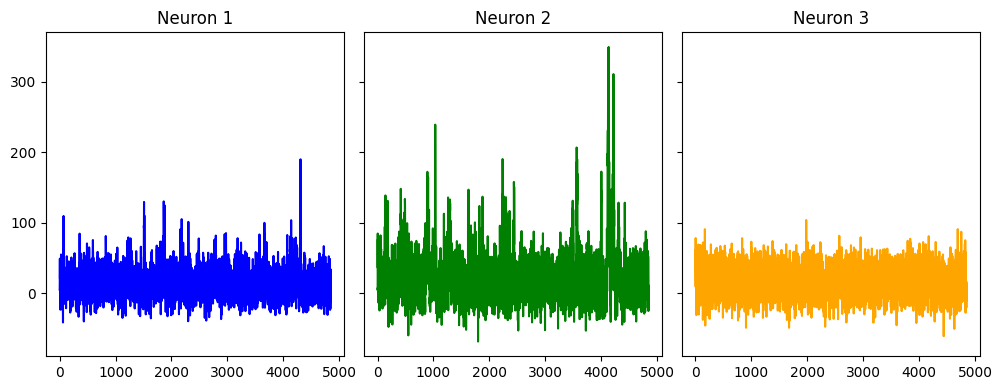

In [ ]:
# Plot of 3 neurons
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 4), sharey=True)
ax1.plot(np.arange(0, data.shape[1]), data[0,:], label="Neuron 1", color='blue')
ax2.plot(np.arange(0, data.shape[1]), data[1,:], label="Neuron 2", color='green')
ax3.plot(np.arange(0, data.shape[1]), data[2,:], label="Neuron 3", color='orange')
ax1.set_title("Neuron 1")
ax2.set_title("Neuron 2")
ax3.set_title("Neuron 3")
plt.tight_layout()
plt.show()

In [6]:
# Relative change normalization (deltaF/F0)
window_size = 300
n_neurons, n_frames = data.shape

norm_data = np.zeros_like(data, dtype=float)

for i in range(n_neurons):
# for i in range(1):
    neuron = data[i]
    for t in range(n_frames):
        start = max(0, t - window_size)
        if t == 0:
            F0 = neuron[0]
        else:
            window = neuron[start:t]
            if window.size <= 1:
                F0 = neuron[0]
            else:
                median = np.percentile(window, 50)
                lower_half = window[window < median]
                F0 = np.mean(lower_half)
        if F0 == 0:
            F0 = 1e-6
        norm_data[i, t] = (neuron[t] - F0) / F0
    if i % 10 == 0:
        print(f"Neuron {i+1} normalized")

Neuron 1 normalized
Neuron 2 normalized
Neuron 3 normalized
Neuron 4 normalized
Neuron 5 normalized
Neuron 6 normalized
Neuron 7 normalized
Neuron 8 normalized
Neuron 9 normalized
Neuron 10 normalized
Neuron 11 normalized
Neuron 12 normalized
Neuron 13 normalized
Neuron 14 normalized
Neuron 15 normalized
Neuron 16 normalized
Neuron 17 normalized
Neuron 18 normalized
Neuron 19 normalized
Neuron 20 normalized
Neuron 21 normalized
Neuron 22 normalized
Neuron 23 normalized
Neuron 24 normalized
Neuron 25 normalized
Neuron 26 normalized
Neuron 27 normalized
Neuron 28 normalized
Neuron 29 normalized
Neuron 30 normalized
Neuron 31 normalized
Neuron 32 normalized
Neuron 33 normalized
Neuron 34 normalized
Neuron 35 normalized
Neuron 36 normalized
Neuron 37 normalized
Neuron 38 normalized
Neuron 39 normalized
Neuron 40 normalized
Neuron 41 normalized
Neuron 42 normalized
Neuron 43 normalized
Neuron 44 normalized
Neuron 45 normalized
Neuron 46 normalized
Neuron 47 normalized
Neuron 48 normalized
N

In [ ]:
# Write norm_data to csv
# np.savetxt("norm_data.csv", norm_data, delimiter=",")

# Read norm_data from csv
norm_data = np.genfromtxt("norm_data.csv", delimiter=",")

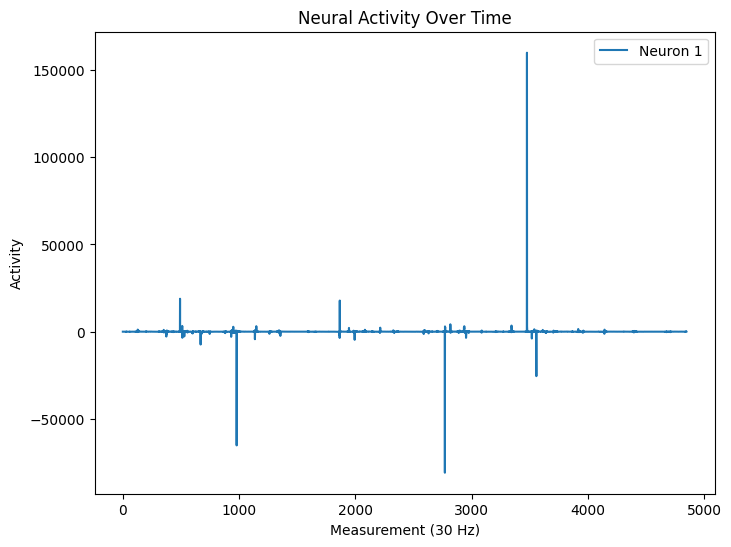

In [21]:
# Plot normalized data for neuron 1
plt.figure(figsize=(8, 6))
plt.plot(norm_data[0,:], label="Neuron 1")
plt.xlabel("Measurement (30 Hz)")
plt.ylabel("Activity")
plt.title("Neural Activity Over Time")
plt.legend()
plt.show()

# 2 Pearson correlation

### 2.1 Correlation matrix summary (plot and stats)

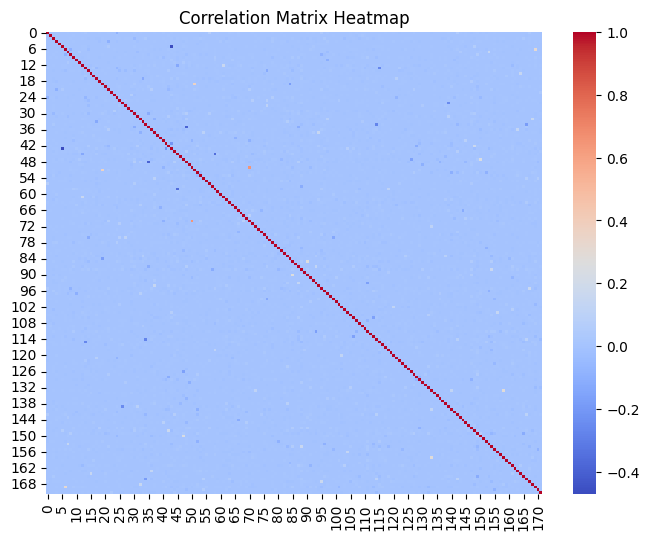

[[ 1.00000000e+00 -1.31250755e-03 -9.41155259e-04 ... -9.42220444e-04
   6.55226590e-05  5.80925275e-04]
 [-1.31250755e-03  1.00000000e+00  3.88887914e-04 ... -1.71118413e-03
  -4.26907746e-04  3.38550624e-04]
 [-9.41155259e-04  3.88887914e-04  1.00000000e+00 ...  1.30982685e-03
  -1.15812659e-03 -8.80405401e-04]
 ...
 [-9.42220444e-04 -1.71118413e-03  1.30982685e-03 ...  1.00000000e+00
   1.44538349e-02  5.24778280e-03]
 [ 6.55226590e-05 -4.26907746e-04 -1.15812659e-03 ...  1.44538349e-02
   1.00000000e+00  2.15036492e-04]
 [ 5.80925275e-04  3.38550624e-04 -8.80405401e-04 ...  5.24778280e-03
   2.15036492e-04  1.00000000e+00]]
[1.72267608e-06 8.85773222e-07 3.46630130e-07 ... 2.08913343e-04
 2.75392243e-05 4.62406930e-08]
                R^2
count  1.470600e+04
mean   2.112717e-04
std    4.791564e-03
min    2.379795e-15
25%    1.416074e-07
50%    1.006625e-06
75%    7.295223e-06
max    4.177884e-01


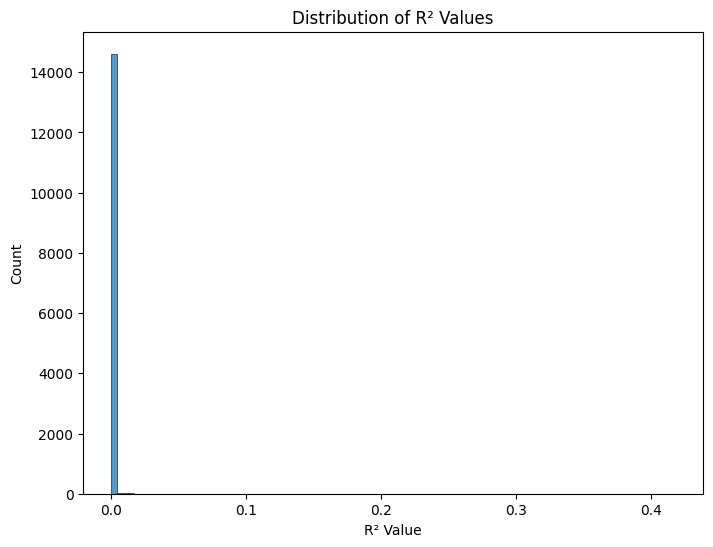

In [48]:
corr_matrix = np.corrcoef(norm_data)

# Plot correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

# Summary stats for r^2 values
corr_matrix = np.corrcoef(norm_data)
print(corr_matrix)
r2_vals = np.square(corr_matrix[np.triu_indices_from(corr_matrix, k=1)])
print(r2_vals)
df = pd.DataFrame(r2_vals, columns=['R^2'])
print(df.describe())

# Plot histogram of r^2 values
plt.figure(figsize=(8, 6))
sns.histplot(r2_vals, bins=100)
plt.xlabel('R² Value')
plt.title('Distribution of R² Values')
plt.show()

### 2.2 Thresholded correlation matrix

In [10]:
# Analyze correlation matrix with different thresholds
for i in range(0, 5):
    corr_matrix = np.corrcoef(norm_data)

    # Remove self-correlations
    np.fill_diagonal(corr_matrix, 0)

    # Threshold weak correlations
    threshold = 0.01 * i
    corr_matrix[np.abs(corr_matrix) < threshold] = 0

    # Create undirected weighted graph
    G = nx.from_numpy_array(corr_matrix, create_using=nx.DiGraph)

    print(f"r > {threshold:.2f}: {G.number_of_edges()} edges")

r > 0.00: 29412 edges
r > 0.01: 1900 edges
r > 0.02: 766 edges
r > 0.03: 464 edges
r > 0.04: 330 edges


In [11]:
for i in range(5, 20):
    corr_matrix = np.corrcoef(norm_data)

    # Remove self-correlations
    np.fill_diagonal(corr_matrix, 0)

    # Threshold weak correlations
    threshold = 0.01 * i
    corr_matrix[np.abs(corr_matrix) < threshold] = 0

    # Create undirected weighted graph
    G = nx.from_numpy_array(corr_matrix, create_using=nx.DiGraph)

    pos = nx.spring_layout(G, seed=42)

    # nx.draw(G, pos, node_color='skyblue', node_size=100)

    # nx.draw_networkx_edges(G, pos, width=2, edge_color='black')

    # plt.title(f"Thresholded Pearson Correlation Network (r > {threshold:.2f})")
    # plt.show()

    print(f"r > {threshold:.2f}: {G.number_of_edges()} edges")
    nx.write_graphml(G, f"neurons{threshold*100:.0f}.graphml")

r > 0.05: 246 edges
r > 0.06: 196 edges
r > 0.07: 164 edges
r > 0.08: 140 edges
r > 0.09: 118 edges
r > 0.10: 96 edges
r > 0.11: 82 edges
r > 0.12: 70 edges
r > 0.13: 62 edges
r > 0.14: 52 edges
r > 0.15: 46 edges
r > 0.16: 42 edges
r > 0.17: 30 edges
r > 0.18: 28 edges
r > 0.19: 26 edges


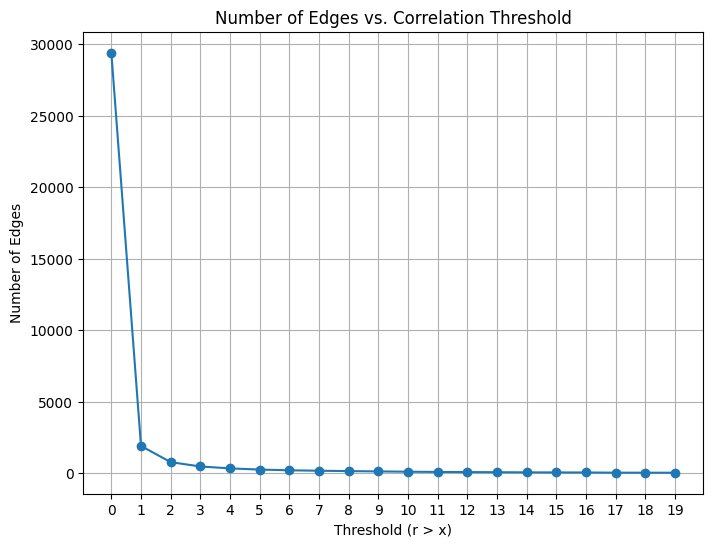

In [12]:
# Plot number of edges vs. threshold
num_edges = [29412, 1900, 766, 464, 330, 246, 196, 164, 140, 118, 96, 82, 70, 62, 52, 46, 42, 30, 28, 26]

plt.figure(figsize=(8, 6))
plt.plot(range(0, 20), num_edges, marker='o')
plt.xlabel('Threshold (r > x)')
plt.ylabel('Number of Edges')
plt.title('Number of Edges vs. Correlation Threshold')
plt.xticks(range(0, 20))
plt.grid()
plt.show()

### 2.3 p-value analysis

In [13]:
# Output a matrix with calculated p-values for the correlation matrix
n_neurons = norm_data.shape[0]
p_matrix = np.ones((n_neurons, n_neurons))
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        if i != j:
            p_matrix[i, j] = stats.pearsonr(norm_data[i], norm_data[j])[1]
    if i % 10 == 0:
        print(f"Calculated p-values for neuron {i+1}")

    p_matrix[i, i] = 0  # self-comparison

Calculated p-values for neuron 1
Calculated p-values for neuron 11
Calculated p-values for neuron 21
Calculated p-values for neuron 31
Calculated p-values for neuron 41
Calculated p-values for neuron 51
Calculated p-values for neuron 61
Calculated p-values for neuron 71
Calculated p-values for neuron 81
Calculated p-values for neuron 91
Calculated p-values for neuron 101
Calculated p-values for neuron 111
Calculated p-values for neuron 121
Calculated p-values for neuron 131
Calculated p-values for neuron 141
Calculated p-values for neuron 151
Calculated p-values for neuron 161
Calculated p-values for neuron 171


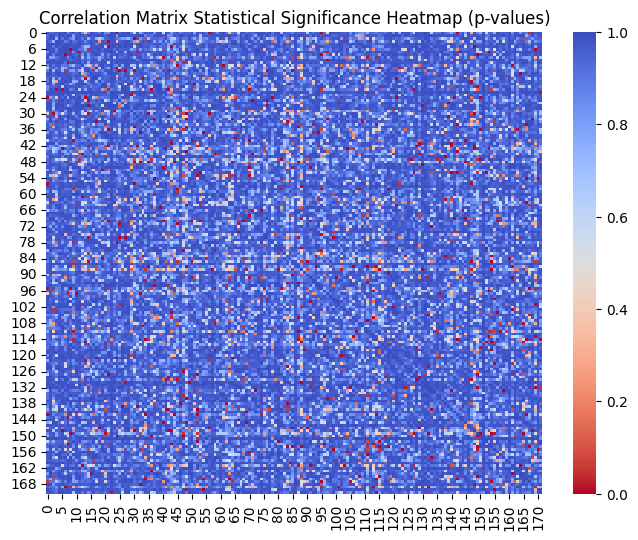

In [16]:
# Plot p-value matrix
np.fill_diagonal(p_matrix, 1)
plt.figure(figsize=(8, 6))
sns.heatmap(p_matrix, cmap='coolwarm_r')
plt.title('Correlation Matrix Statistical Significance Heatmap (p-values)')
plt.show()

# *** All code past this point was not used for community detection ***

# 3 Transfer entropy

### 3.1 Transfer entropy matrix

In [18]:
# Coalesce the series to positive integers for transfer entropy calculation in PyInform
def coalesce_row(row):
    # Returns (coalesced_row, base)
    return coalesce_series(row)[0]
coalesced_data = np.apply_along_axis(coalesce_row, 1, norm_data)

te_matrix = np.zeros((n_neurons, n_neurons))

k = 1  # history length

for i in range(n_neurons):
    for j in range(n_neurons):
        if i != j:
            te_matrix[i, j] = transfer_entropy(coalesced_data[i], coalesced_data[j], k=k)
    if i % 10 == 0:
        print(f"Calculated transfer entropy for neuron {i+1}")

# Transfer entropy matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(te_matrix, cmap='coolwarm')
plt.title('Transfer Entropy Matrix Heatmap')
plt.show()

Calculated transfer entropy for neuron 1
Calculated transfer entropy for neuron 2
Calculated transfer entropy for neuron 3
Calculated transfer entropy for neuron 4
Calculated transfer entropy for neuron 5
Calculated transfer entropy for neuron 6
Calculated transfer entropy for neuron 7
Calculated transfer entropy for neuron 8
Calculated transfer entropy for neuron 9
Calculated transfer entropy for neuron 10
Calculated transfer entropy for neuron 11
Calculated transfer entropy for neuron 12
Calculated transfer entropy for neuron 13
Calculated transfer entropy for neuron 14
Calculated transfer entropy for neuron 15
Calculated transfer entropy for neuron 16
Calculated transfer entropy for neuron 17
Calculated transfer entropy for neuron 18
Calculated transfer entropy for neuron 19
Calculated transfer entropy for neuron 20
Calculated transfer entropy for neuron 21
Calculated transfer entropy for neuron 22
Calculated transfer entropy for neuron 23
Calculated transfer entropy for neuron 24
C

KeyboardInterrupt: 

### 3.2 p-value analysis

In [17]:
# Now compute p-values using surrogate data
n_surrogates = 100
p_matrix = np.ones((n_neurons, n_neurons))

# Compute p-values for all pairs (i, j)
for i in range(n_neurons):
    for j in range(n_neurons):
        if i == j:
            continue
        source = coalesced_data[i]
        target = coalesced_data[j]
        true_te = te_matrix[i, j]
        null_dist = np.zeros(n_surrogates)
        for s in range(n_surrogates):
            shift = np.random.randint(len(source))
            surrogate = np.roll(source, shift)
            null_dist[s] = transfer_entropy(surrogate, target, k=1)
        p_matrix[i, j] = np.mean(null_dist >= true_te)
sig_te = np.where(p_matrix < 0.05, te_matrix, 0)

plt.figure(figsize=(8, 6))
sns.heatmap(sig_te, cmap='coolwarm_r')
plt.title('Transfer Entropy (p < 0.05) Heatmap')
plt.xlabel('Target neuron')
plt.ylabel('Source neuron')
plt.show()

NameError: name 'coalesced_data' is not defined